# Cluster similarity with CellHint

Based on: https://github.com/Teichlab/cellhint/blob/main/docs/notebook/cellhint_tutorial_harmonisation.ipynb

In [1]:
%load_ext autoreload

In [2]:

import pickle
from os.path import join, isfile

import anndata
import cellhint
import numpy as np
import scanpy as sc
from IPython.display import display, Markdown

/vol/data/miniconda3/envs/cellhint/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%autoreload
from sconnect.plotting import plot_cluster_mapping

## Load data

In [4]:
CACHE_DIR = "/vol/data/dataset-similarity/cache"
SAVE_DIR = "/vol/data/dataset-similarity/models/CellHint"
FIG_DIR = "/vol/data/dataset-similarity/figures/CellHint"

QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"

N_TOP_GENES = 3000

In [5]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [6]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'batch', 'ct1', 'ct2', 'ct3', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab'

In [7]:
adata_ref

AnnData object with n_obs × n_vars = 1265624 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'sample_uuid', 'author_cell_type', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab', 'X_scimilarity'

In [8]:
adata = anndata.concat(
    [adata_query, adata_ref], 
    label="dataset", 
    keys=["query", "ref"]
)
adata

AnnData object with n_obs × n_vars = 1866553 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'sample_id', 'dataset'
    obsm: 'X_scTab'

In [9]:
# normalize and compute PCA for CellHint
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# Data is already subset to 3000 highly variable genes -> skip this step
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
adata

AnnData object with n_obs × n_vars = 1866553 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'sample_id', 'dataset'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_scTab', 'X_pca'
    varm: 'PCs'

In [10]:
order_index = [
    'B_Mem',
    'B_Mem_Prolif',
    'B_Naive',
    'B_Preplasma',
    'NKT',
    'NK_CD16+',
    'NK_CD56++',
    'NK_Prolif',
    'PB',
    'PB_Prolif',
    'Progen_CLP',
    'Progen_CMP',
    'Progen_MEP',
    'Progen_MPP',
    'T4_Mem',
    'T4_Mem_Prolif',
    'T4_Naive',
    'T4_Treg',
    'T8_MAIT',
    'T8_Mem',
    'T8_Mem_Prolif',
    'T8_Naive',
    'T_NK_Prolif',
    'Tgd_1',
    'Tgd_2',
    'cDC_1',
    'cDC_2',
    'pDC',
    'cM',
    'ncM',
]

In [11]:
order_columns = [
    'memory_B',
    'memory_B_IGHMhi',
    'memory_B_IGHMlo',
    'naive_B',
    'atypical_B',
    'B_unknown',
    'NK',
    'CD16+_NK',
    'CD56+_NK',
    'Plasma_Cell',
    'Platelet',
    'CD34_HSPC',
    'CD4+_T',
    'CD4+_T_cm',
    'CD4+_T_cyt',
    'CD4+_T_em',
    'CD4+_T_naive',
    'Treg',
    'CD8+_T_GZMBhi',
    'CD8+_T_GZMKhi',
    'CD8+_T_naive',
    'CD8+_T_unknown',
    'MAIT',
    'dnT',
    'gdT_GZMBhi',
    'gdT_GZMKhi',
    'T_unknown',
    'cDC1',
    'cDC2',
    'DC_SIGLEC6hi',
    'pDC',
    'Myeloid',
    'CD14+_Monocyte',
    'CD16+_Monocyte',
    'ILC',
]

## Run CellHint with `use_pct=False`

In [26]:
model_file = join(SAVE_DIR, f"{QUERY_DATASET}+{REF_DATASET}+use_pct=False.pkl")

if isfile(model_file):
    print("Using cached model...")
    with open(model_file, "rb") as f:
        alignment_wo_pct = pickle.load(f)
else:
    alignment_wo_pct = cellhint.harmonize(
        adata, 
        dataset="dataset", 
        cell_type="cell_type_author", 
        use_rep="X_pca",
        dataset_order=["query", "ref"],
        use_pct=False
    )
    alignment_wo_pct.write(model_file)

Using cached model...


In [27]:
top_n_labels = {}

for ct in np.unique(adata_query.obs["cell_type_author"]):
    top_hits = alignment_wo_pct.relation.query(f"`query` == '{ct}'")["ref"].tolist()
    if top_hits == ["UNRESOLVED"] or top_hits == ["NONE"]:
        top_hits = []
    top_n_labels[ct] = top_hits

summaries = []
for i, (k, v) in enumerate(sorted(top_n_labels.items(), key=lambda x: x[0])):
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))

*1*: **B_Mem**: [] <br>*2*: **B_Mem_Prolif**: ['memory_B_IGHMlo'] <br>*3*: **B_Naive**: [] <br>*4*: **B_Preplasma**: ['B_unknown', 'atypical_B'] <br>*5*: **NKT**: [] <br>*6*: **NK_CD16+**: ['CD16+_NK', 'NK'] <br>*7*: **NK_CD56++**: ['ILC'] <br>*8*: **NK_Prolif**: [] <br>*9*: **PB**: ['Plasma_Cell'] <br>*10*: **PB_Prolif**: [] <br>*11*: **Progen_CLP**: ['CD34_HSPC'] <br>*12*: **Progen_CMP**: ['CD34_HSPC'] <br>*13*: **Progen_MEP**: ['CD34_HSPC'] <br>*14*: **Progen_MPP**: [] <br>*15*: **T4_Mem**: ['CD4+_T', 'CD4+_T_naive'] <br>*16*: **T4_Mem_Prolif**: ['CD4+_T_cm', 'CD4+_T_em', 'Treg', 'dnT'] <br>*17*: **T4_Naive**: [] <br>*18*: **T4_Treg**: [] <br>*19*: **T8_MAIT**: ['MAIT', 'gdT_GZMKhi'] <br>*20*: **T8_Mem**: [] <br>*21*: **T8_Mem_Prolif**: ['CD4+_T_cyt', 'CD8+_T_GZMBhi'] <br>*22*: **T8_Naive**: ['CD8+_T_naive', 'T_unknown'] <br>*23*: **T_NK_Prolif**: [] <br>*24*: **Tgd_1**: ['CD8+_T_unknown', 'gdT_GZMBhi'] <br>*25*: **Tgd_2**: [] <br>*26*: **cDC_1**: ['cDC1'] <br>*27*: **cDC_2**: ['cDC2'] <br>*28*: **cM**: ['CD14+_Monocyte'] <br>*29*: **ncM**: ['CD16+_Monocyte'] <br>*30*: **pDC**: ['pDC'] <br>

In [28]:
mapping = alignment_wo_pct.base_distance.to_meta()
mapping = mapping.loc[
    mapping.index.str.startswith("query"),
    mapping.columns.str.startswith("ref")
]
mapping.index = mapping.index.str.removeprefix("query: ")
mapping.columns = mapping.columns.str.removeprefix("ref: ")

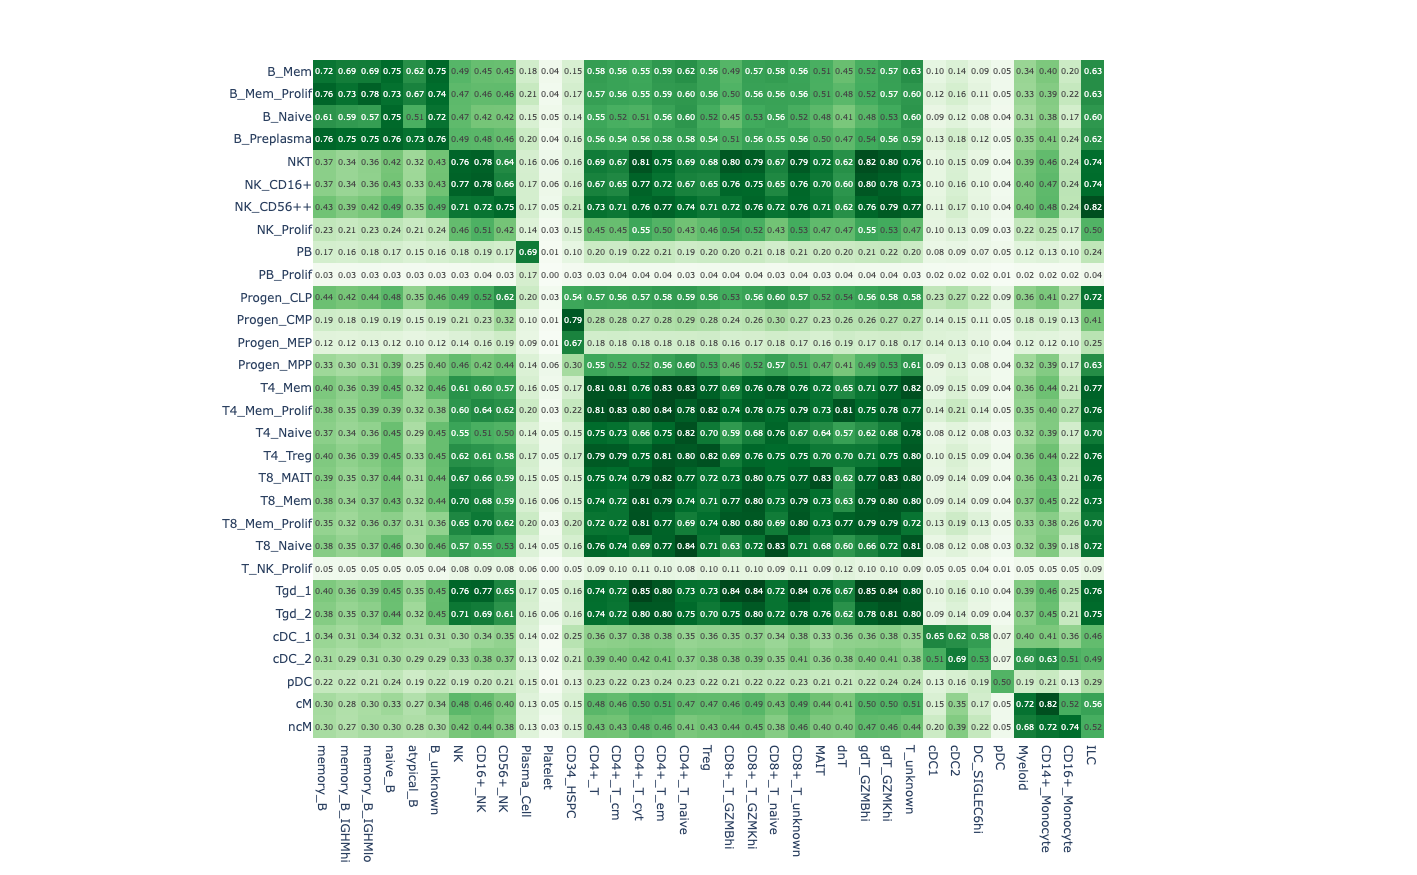

In [29]:
if QUERY_DATASET in [
    "f6c50495-3361-40ed-a819-fb9644396ed9",
    "0f528c8a-a25c-4840-8fa3-d156fa11086f"
]:
    mapping = mapping.T

fig = plot_cluster_mapping((-mapping + 1.).loc[order_index, order_columns], show=False, sort_by_score=False)
fig.update_layout(coloraxis_showscale=False)

In [30]:
(-mapping + 1.).to_parquet("cellhint_mappping.parquet")

In [31]:
fig.write_image("plots/CellHint-no-pct-immune-example.svg")

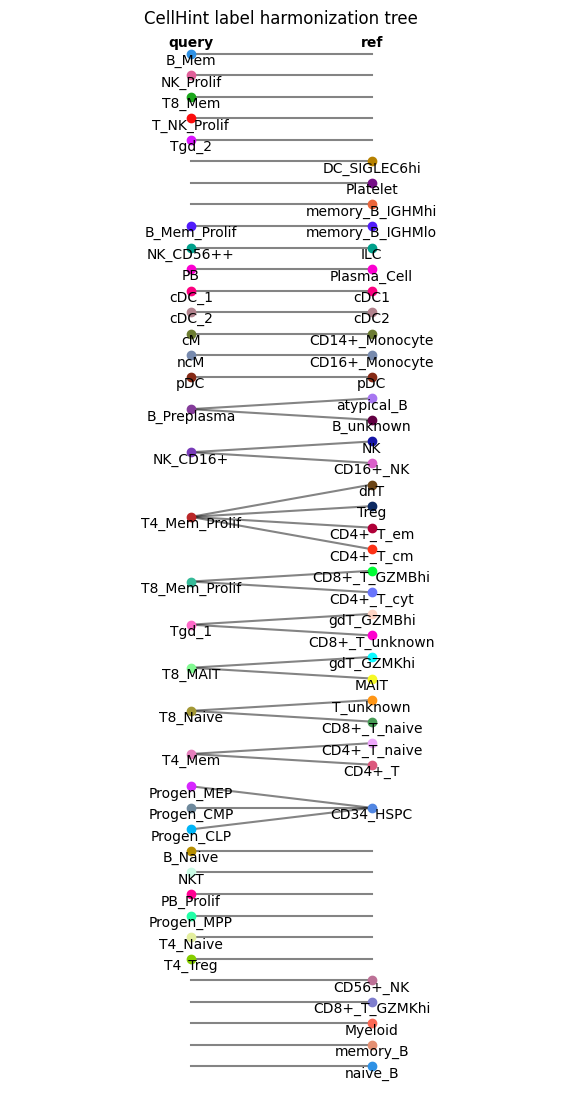

In [49]:
cellhint.treeplot(alignment_wo_pct, save="plots/cellhint_treeplot_pct=False.svg")

In [51]:
alignment_wo_pct.relation.sort_values("query")

,query,relation,ref
0,B_Mem,=,NONE
0,B_Mem_Prolif,=,memory_B_IGHMlo
0,B_Naive,=,UNRESOLVED
1,B_Preplasma,∋,atypical_B
0,B_Preplasma,∋,B_unknown
1,NKT,=,UNRESOLVED
3,NK_CD16+,∋,NK
2,NK_CD16+,∋,CD16+_NK
1,NK_CD56++,=,ILC
1,NK_Prolif,=,NONE


## Run CellHint with `use_pct=True`

In [37]:
model_file = join(SAVE_DIR, f"{QUERY_DATASET}+{REF_DATASET}+use_pct=True.pkl")

if isfile(model_file):
    print("Using cached model...")
    with open(model_file, "rb") as f:
        alignment = pickle.load(f)
else:
    alignment = cellhint.harmonize(
        adata, 
        dataset="dataset", 
        cell_type="cell_type_author",
        use_rep="X_pca",
        dataset_order=["query", "ref"],
        use_pct=True
    )
    alignment.write(model_file)

Using cached model...


In [38]:
top_n_labels = {}

for ct in np.unique(adata_query.obs["cell_type_author"]):
    top_hits = alignment.relation.query(f"`query` == '{ct}'")["ref"].tolist()
    if top_hits == ["UNRESOLVED"] or top_hits == ["NONE"]:
        top_hits = []
    top_n_labels[ct] = top_hits

summaries = []
for i, (k, v) in enumerate(sorted(top_n_labels.items(), key=lambda x: x[0])):
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))

*1*: **B_Mem**: ['B_unknown'] <br>*2*: **B_Mem_Prolif**: [] <br>*3*: **B_Naive**: ['B_unknown'] <br>*4*: **B_Preplasma**: ['memory_B', 'naive_B'] <br>*5*: **NKT**: ['CD56+_NK'] <br>*6*: **NK_CD16+**: ['CD16+_NK', 'NK'] <br>*7*: **NK_CD56++**: ['CD56+_NK'] <br>*8*: **NK_Prolif**: [] <br>*9*: **PB**: ['Plasma_Cell'] <br>*10*: **PB_Prolif**: [] <br>*11*: **Progen_CLP**: [] <br>*12*: **Progen_CMP**: ['CD34_HSPC'] <br>*13*: **Progen_MEP**: ['CD34_HSPC'] <br>*14*: **Progen_MPP**: [] <br>*15*: **T4_Mem**: ['CD4+_T_em', 'CD4+_T_naive'] <br>*16*: **T4_Mem_Prolif**: ['CD4+_T', 'CD4+_T_cm', 'Treg', 'dnT'] <br>*17*: **T4_Naive**: ['T_unknown'] <br>*18*: **T4_Treg**: [] <br>*19*: **T8_MAIT**: [] <br>*20*: **T8_Mem**: ['T_unknown'] <br>*21*: **T8_Mem_Prolif**: ['CD8+_T_GZMBhi', 'CD8+_T_GZMKhi'] <br>*22*: **T8_Naive**: [] <br>*23*: **T_NK_Prolif**: [] <br>*24*: **Tgd_1**: ['CD4+_T_cyt', 'CD8+_T_unknown', 'gdT_GZMBhi', 'gdT_GZMKhi'] <br>*25*: **Tgd_2**: [] <br>*26*: **cDC_1**: ['cDC1'] <br>*27*: **cDC_2**: ['CD14+_Monocyte'] <br>*28*: **cM**: ['CD14+_Monocyte'] <br>*29*: **ncM**: ['CD14+_Monocyte'] <br>*30*: **pDC**: ['pDC'] <br>

In [39]:
mapping = alignment.base_distance.to_meta()
mapping = mapping.loc[
    mapping.index.str.startswith("query"),
    mapping.columns.str.startswith("ref")
]
mapping.index = mapping.index.str.removeprefix("query: ")
mapping.columns = mapping.columns.str.removeprefix("ref: ")

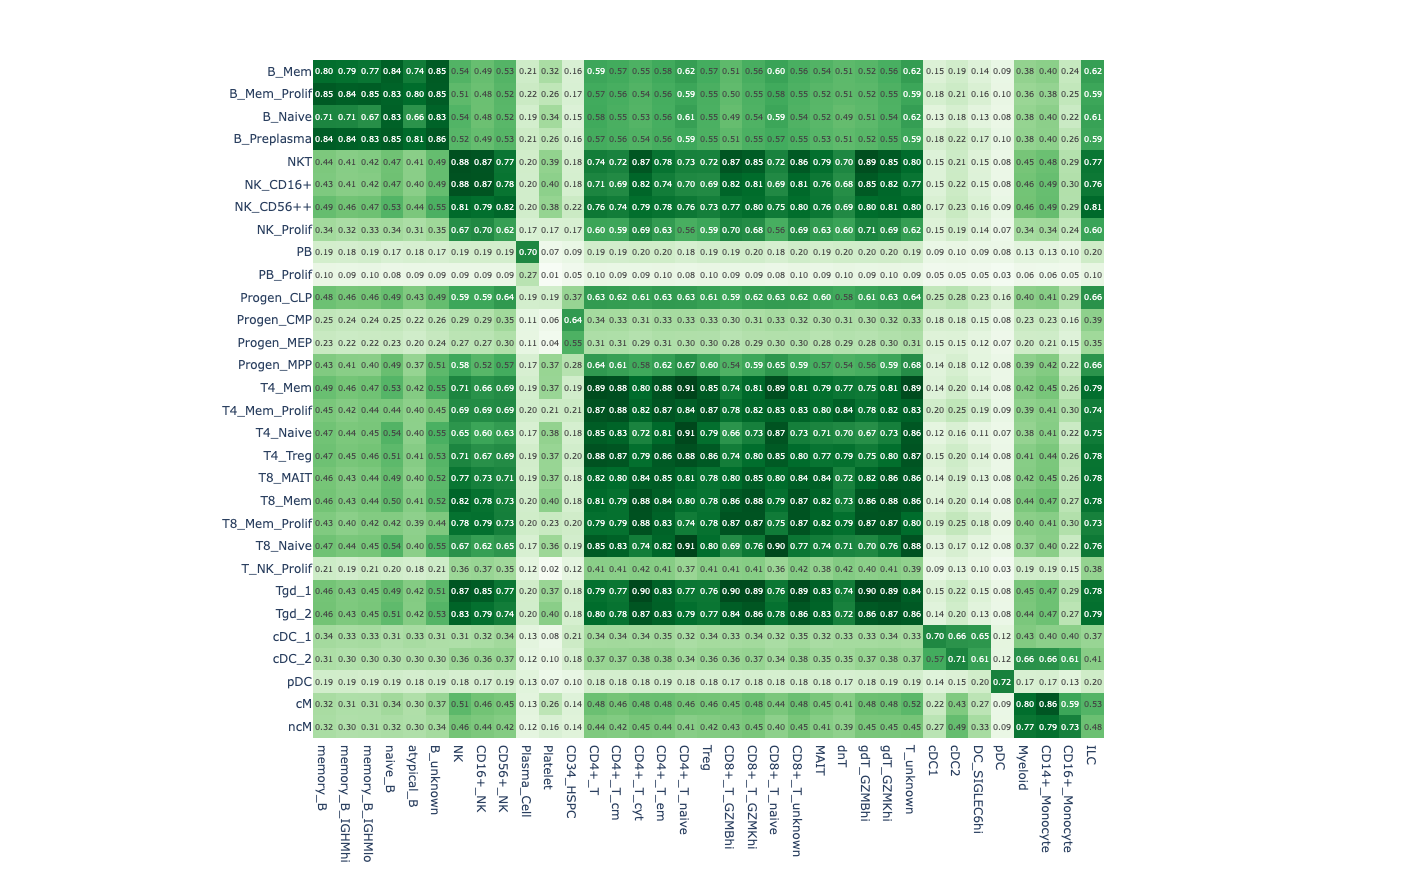

In [40]:
fig = plot_cluster_mapping((-mapping + 1.).loc[order_index, order_columns], show=False, sort_by_score=False)
fig.update_layout(coloraxis_showscale=False)

In [41]:
fig.write_image("plots/CellHint-immune-example_pct+True.svg")

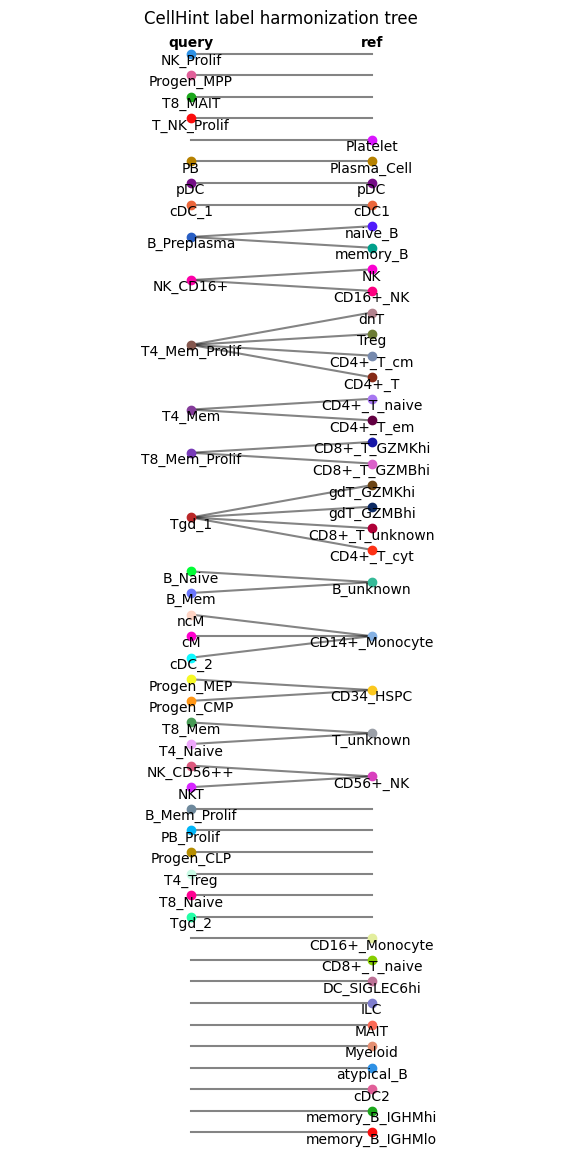

In [48]:
cellhint.treeplot(alignment, save="plots/cellhint_treeplot_pct=True.svg")

In [52]:
alignment.relation.sort_values("query")

,query,relation,ref
0,B_Mem,∈,B_unknown
0,B_Mem_Prolif,=,UNRESOLVED
1,B_Naive,∈,B_unknown
1,B_Preplasma,∋,naive_B
0,B_Preplasma,∋,memory_B
0,NKT,∈,CD56+_NK
3,NK_CD16+,∋,NK
2,NK_CD16+,∋,CD16+_NK
1,NK_CD56++,∈,CD56+_NK
0,NK_Prolif,=,NONE
